In [ ]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import os
import gc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib as mpl
from matplotlib import colors
from matplotlib.lines import Line2D

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

def get_dotplot_df(adata, annotation_col, genes_for_plot, expression_cutoff=0, 
                   standard_var=False, standard_method='zscore',
                   cap=None, floor=None):
    # cap / floor are quantiles (e.g. cap=0.99, floor=0.01)

    import numpy as np
    import scipy.sparse as sp
    import pandas as pd
    from scipy.stats import zscore

    # filter the anndata by genes needed for plot
    ad = adata[:, adata.var_names.isin(genes_for_plot)].copy()

    # ensure dense matrix for manipulation
    X = ad.X.toarray() if sp.issparse(ad.X) else ad.X.copy()

    # --- NEW: apply per-gene clipping ---
    if cap is not None or floor is not None:
        for i, gene in enumerate(ad.var_names):
            gene_expr = X[:, i]

            if floor is not None:
                floor_value = np.quantile(gene_expr, floor)
            else:
                floor_value = gene_expr.min()

            if cap is not None:
                cap_value = np.quantile(gene_expr, cap)
            else:
                cap_value = gene_expr.max()

            X[:, i] = np.clip(gene_expr, floor_value, cap_value)

    # convert to df
    df = pd.DataFrame(
        X,
        index=[ad.obs['cell_id'], ad.obs[annotation_col]],
        columns=ad.var_names
    )

    # get mean per group
    group_mean = df.reset_index().drop('cell_id', axis=1)\
        .groupby(annotation_col, observed=True).mean()

    # normalise/standardise the group mean
    if standard_var:
        if standard_method == 'zscore':
            group_mean = group_mean.apply(zscore, axis=0)
        elif standard_method == 'minmax':
            group_mean = (group_mean - group_mean.min(axis=0)) / (
                group_mean.max(axis=0) - group_mean.min(axis=0)
            )

    # melt df for plotting
    group_mean = group_mean.melt(ignore_index=False, var_name="feature")\
        .reset_index().set_index([annotation_col, 'feature'])\
        .rename(columns={'value': 'mean'})

    # calculate cell fraction
    cell_fraction = (df > expression_cutoff).reset_index()\
        .drop('cell_id', axis=1)\
        .groupby(annotation_col, observed=True).sum().divide(
            df.reset_index().groupby(annotation_col, observed=True)['cell_id'].count(),
            axis=0
        )\
        .melt(ignore_index=False, var_name="feature")\
        .reset_index().set_index([annotation_col, 'feature'])\
        .rename(columns={'value': 'proportion'})

    # return concatenated mean and fraction
    return pd.concat([group_mean, cell_fraction], axis=1).reset_index()

reference_dir = '../../../data/GBM_LEAP_annotations/'
output_dir = '../../../data/EDFig10/'

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
adata = sc.read_h5ad(os.path.join(reference_dir, 'GBM_LEAP_annotations_v2.22_04_25.webatlas.h5ad'))
adata = adata[adata.obs['annotation_coarse']=='Myeloid']
adata = adata[:,adata.var['feature_types']=='Gene Expression']

# normalise
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [ ]:
genes = [
    "SPP1",
    "TGFB1",
    "APOE",
    "LGALS9",
    "APOC2",
    "IL18",
    "HLA-E",
    "C3",
    "ST6GAL1",
    "TNFSF10",
    "ADAM10",
    "IGF1",
    "CD14",
    "HMGB1",
    "THBS1",
    "GRN",
    "GPI",
    "CXCL8",
    "VCAN",
    "ADAM9",
    "ADM",
    "ANGPTL4",
    "VEGFA",
    "VIM",
    "LGALS8",
    "ANXA1"
]

In [ ]:
paper_order = [
    "Angiogenic TAMs",
    "Stress-response TAMs",
    "Anti-inflammatory TAMs",
    "Resident BAM TAMs",
    "Proliferative TAMs",
    "RTN1+ TAMs",
    "Monocytes",
    "Interferon TAMs",
    "Pro-inflammatory TAMs",
    "Astrocyte-like TAMs", 
    "Resident-TAMs",

]

In [ ]:
dp_df = get_dotplot_df(
    adata[adata.obs['annotation_granular'].isin(paper_order)],
    'annotation_granular',
    genes,
    standard_var=True,
    standard_method='zscore',
    cap=1,
    floor=0
)

In [ ]:
dp_df["annotation_granular"] = pd.Categorical(
    dp_df["annotation_granular"],
    categories=paper_order,
    ordered=True
)

dp_df["feature"] = pd.Categorical(
    dp_df["feature"],
    categories=genes,
    ordered=True
)

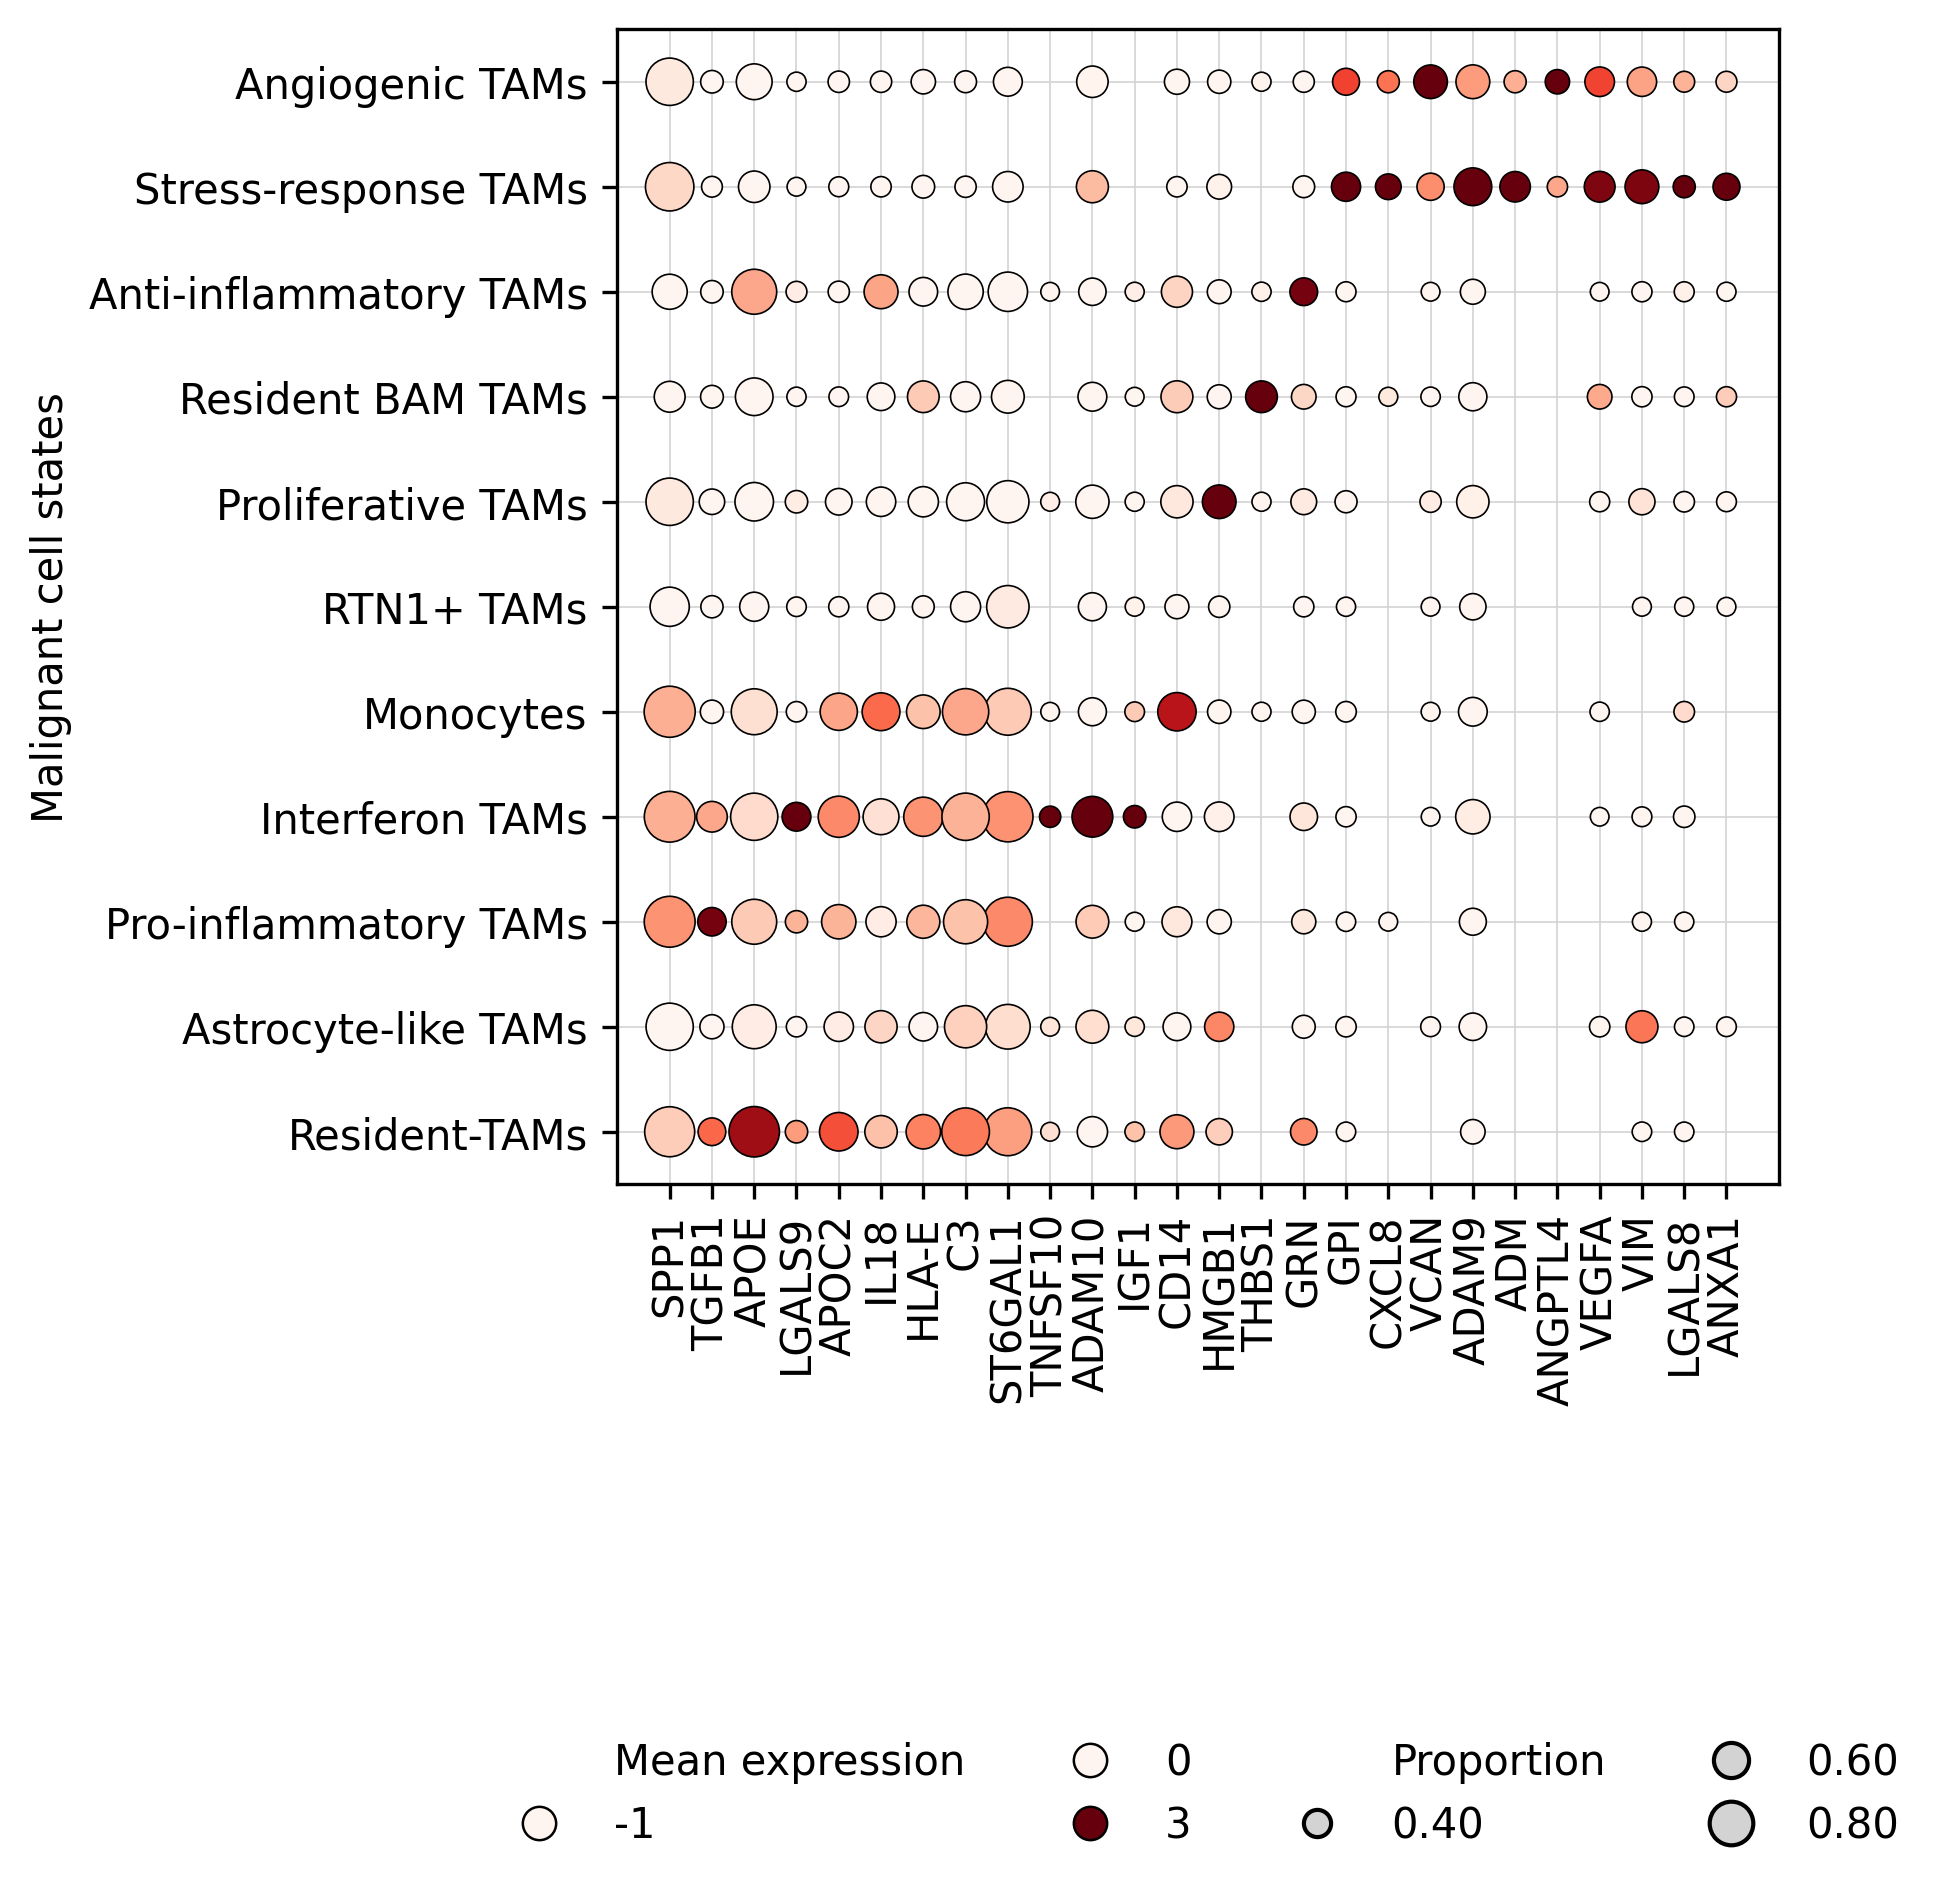

In [ ]:
# --- FILTER: drop low-proportion dots ---
dp_df_plot = dp_df[dp_df['proportion'] >= 0.05].copy()

# Color scaling
vmax = np.quantile(dp_df_plot['mean'], 0.99)
norm = colors.TwoSlopeNorm(vmin=0, vcenter=1.6, vmax=2)
cmap = plt.get_cmap('Reds')

# --- Dot-size scaling ---
size_min, size_max = 20, 150
pmin, pmax = dp_df_plot['proportion'].min(), dp_df_plot['proportion'].max()

prop_scaled = (dp_df_plot['proportion'] - pmin) / (pmax - pmin)
prop_scaled = np.clip(prop_scaled, 0, 1)
size_exp = 1.8

dp_df_plot['dot_area'] = size_min + (size_max - size_min) * (prop_scaled ** size_exp)

plt.figure(figsize=(5, 5))

ax = sns.scatterplot(
    data=dp_df_plot,
    x='feature',
    y='annotation_granular',
    hue='mean',
    size='dot_area',
    sizes=(size_min, size_max),
    palette='Reds',
    hue_norm=norm,
    edgecolor='black',
    linewidth=0.4,
    legend=False
)

# Grid lines
ax.set_axisbelow(True)
ax.grid(True, axis='x', color='lightgrey', linewidth=0.4)
ax.grid(True, axis='y', color='lightgrey', linewidth=0.4)

plt.xticks(rotation=90)

# --- COLOR LEGEND ---
color_values = [-1, 0, 3]
color_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=8,
        markerfacecolor=cmap(norm(v)),
        markeredgecolor='black',
        markeredgewidth=0.6,
        label=f'{v:g}'
    )
    for v in color_values
]

# --- SIZE LEGEND ---
size_values = [0.4, 0.6, 0.8]
size_handles = []
for v in size_values:
    v_scaled = (v - pmin) / (pmax - pmin)
    v_scaled = np.clip(v_scaled, 0, 1)
    area = size_min + (size_max - size_min) * (v_scaled ** size_exp)
    size_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=np.sqrt(area),
            markerfacecolor='lightgrey',
            markeredgecolor='black',
            label=f'{v:.2f}'
        )
    )

# Combine legends
handles = (
    [Line2D([], [], linestyle='', label='Mean expression')] +
    color_handles +
    [Line2D([], [], linestyle='', label='Proportion')] +
    size_handles
)

labels = [h.get_label() for h in handles]

ax.legend(
    handles,
    labels,
    bbox_to_anchor=(0.5, -0.45),
    loc='upper center',
    ncol=4,
    frameon=False
)

ax.set_xlabel('')
ax.set_ylabel('Malignant cell states')

plt.savefig('../data/annotation_plots/EDFig10d.pdf')
dp_df.to_csv(f'{output_dir}/EDFig10d.csv')